Simple first net

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input, Dropout
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from pathlib import Path

In [3]:
project_root = Path().resolve().parent
df = pd.read_csv(project_root / "data/cleaned.csv", index_col=0)

In [4]:
df["target"] = (
    df['5'] >
    df['0']
    ).astype('int8')
df["target"].sum()

np.int64(55795)

In [5]:
num_cols = df.select_dtypes(include=["number", "bool"]).columns
num_cols = [c for c in num_cols if not (str(c).isdigit() and 0 <= int(c) <= 750)]
df_numeric = df[num_cols]
df_numeric = df_numeric.drop(columns=["transaction_month", "amounts.shares", "amounts.pricePerShare","filing_count_reportingOwner.name", "trades_14d", "holding_change_percent"])
df_numeric

,reportingOwner.relationship.isDirector,reportingOwner.relationship.isOfficer,reportingOwner.relationship.isTenPercentOwner,direct_ownership,month_sin,month_cos,high_frequency_trader,high_price,high_change_in_holdings,boxcox_amounts_shares,boxcox_amounts.pricePerShare,powertransform_holding_change_percent,scaled_filing_count_reportingOwner.name,scaled_trades_14d,kmeans,target
issuer.tradingSymbol,,,,,,,,,,,,,,,,
HBNC,False,True,False,1,5.000000e-01,0.866025,0,0,1,14.810847,2.800167,1.682722,-0.495984,-0.639443,0,0
WLFC,False,False,True,0,5.000000e-01,0.866025,0,0,0,12.763522,2.349076,-0.534718,-0.487419,-0.639443,0,1
WLFC,False,False,True,0,5.000000e-01,0.866025,0,0,0,9.971760,2.357344,-0.949839,-0.487419,-0.565800,1,1
WLFC,False,False,True,0,5.000000e-01,0.866025,0,0,0,10.613207,2.340755,-0.879243,-0.487419,-0.492157,0,0
HXL,False,True,False,1,5.000000e-01,0.866025,0,0,1,9.024040,2.269244,1.074058,-0.547370,-0.639443,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SPE,True,True,False,1,-2.449294e-16,1.000000,1,0,0,4.873516,2.724795,-0.828549,0.159188,-0.713086,1,1
SPE,True,True,False,1,-2.449294e-16,1.000000,1,0,1,11.808925,2.727904,1.346064,0.159188,-0.713086,0,1
SFBC,False,False,True,0,-2.449294e-16,1.000000,1,1,0,2.210827,4.251506,-1.188667,2.150396,-0.713086,1,0


In [6]:
y = df_numeric['target']
x_columns = [col for col in df_numeric.columns if col != "target"]
X = df_numeric[x_columns]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [7]:
model1 = tf.keras.Sequential([
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model1.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model1.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
2035/2035 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.5638 - loss: 0.6881
Epoch 2/10
2035/2035 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5758 - loss: 0.6768
Epoch 3/10
2035/2035 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5787 - loss: 0.6737
Epoch 4/10
2035/2035 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5807 - loss: 0.6711
Epoch 5/10
2035/2035 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5835 - loss: 0.6686
Epoch 6/10
2035/2035 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.5869 - loss: 0.6654
Epoch 7/10
2035/2035 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5879 - loss: 0.6626
Epoch 8/10
2035/2035 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5908 - loss: 0.6597
Epoch 9/10
2035/2035 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5934 - loss: 0.6571
Epoch 10/10
2035/2035 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5967 - loss: 0.6536


In [8]:
model2 = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(1, activation="sigmoid")
])
model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
history = model2.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32
)

c:\Users\tsymb\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.5498 - loss: 0.7020 - val_accuracy: 0.5771 - val_loss: 0.6787
Epoch 2/50
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5717 - loss: 0.6800 - val_accuracy: 0.5757 - val_loss: 0.6775
Epoch 3/50
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5732 - loss: 0.6790 - val_accuracy: 0.5738 - val_loss: 0.6772
Epoch 4/50
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.5745 - loss: 0.6779 - val_accuracy: 0.5754 - val_loss: 0.6783
Epoch 5/50
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.5751 - loss: 0.6773 - val_accuracy: 0.5760 - val_loss: 0.6748
Epoch 6/50
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5761 - loss: 0.6768 - val_accuracy: 0.5737 - val_loss: 0.6741
Epoch 7/50
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.5760 - loss: 0.6755 - val_accuracy: 0.5769 - val_loss: 0.6739
Epoch 8/50
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5773 - loss: 0.6751 -

In [9]:
test_loss, test_acc = model2.evaluate(X_test, y_test)

print("Test accuracy:", test_acc)

1002/1002 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5897 - loss: 0.6678
Test accuracy: 0.5897195935249329


In [10]:
y_pred_prob = model2.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

1002/1002 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [11]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

auc = roc_auc_score(y_test, y_pred_prob)
print("ROC AUC:", auc)

[[ 1120 12435]
 [  719 17787]]
              precision    recall  f1-score   support

           0       0.61      0.08      0.15     13555
           1       0.59      0.96      0.73     18506

    accuracy                           0.59     32061
   macro avg       0.60      0.52      0.44     32061
weighted avg       0.60      0.59      0.48     32061

ROC AUC: 0.5866793040254563


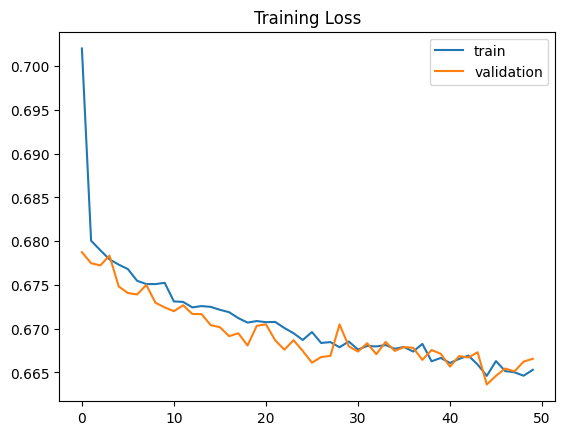

In [12]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend(["train","validation"])
plt.title("Training Loss")
plt.show()